In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quant_mech import ybsoc

from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

In [2]:
hbar = 1.0
k_r = 1.0
m_Yb = 1.0
# delta = 1.5486
# omega_R = 1.0585

delta = 4.0
omega_R = 3.5

In [3]:
qq = np.linspace(-7, 6, 200)

E_up = ybsoc.e1(qq, m_Yb, k_r, delta, omega_R, hbar)
E_down = ybsoc.e2(qq, m_Yb, k_r, delta, omega_R, hbar)

thetas = ybsoc.theta(
    qq,
    delta=delta,
    omega_R=omega_R,
    k_r=k_r,
    m_Yb=m_Yb,
)
alphas = np.cos(thetas)
betas = np.sin(thetas)

In [4]:
ticks = [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]

In [5]:
def soc_hamiltonian(q_x, m_Yb, k_r, delta, omega_R, hbar):
    E_r = (hbar * k_r) ** 2 / (2 * m_Yb)
    return np.array([
        [((hbar ** 2) * (q_x - k_r) ** 2) / (2 * m_Yb) / E_r + delta / 2, omega_R / 2],
        [omega_R / 2, ((hbar ** 2) * (q_x + k_r) ** 2) / (2 * m_Yb) / E_r - delta / 2]
    ])

E_downs_test = []
E_ups_test = []
alphas_test = []
betas_test = []


q_test = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
for q in q_test:
    H = soc_hamiltonian(q, m_Yb, k_r, delta, omega_R, hbar)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    edown, eup = eigenvalues
    psi_down = eigenvectors[:, 0]
    psi_up = eigenvectors[:, 1]
    
    E_ups_test.append(eup)
    E_downs_test.append(edown)
    
    alpha1, beta1 = np.abs(psi_up)
    beta2, alpha2 = np.abs(psi_down)
    assert np.isclose(alpha1, alpha2) and np.isclose(beta1, beta2)
    
    alphas_test.append(alpha1)
    betas_test.append(beta1)
    
    # print(f"Eigenvalues at q_x={q}: {eigenvalues}, Eigenvectors: {eigenvectors.T}")

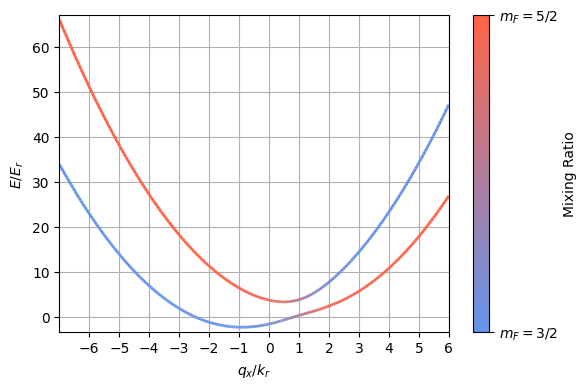

In [6]:
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", ['tomato', 'cornflowerblue'])
# custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", ['red', 'blue'])

color_determining_array_up = np.abs(betas)**2
color_determining_array_down = np.abs(alphas)**2

points_up = np.array([qq, E_up]).T.reshape(-1, 1, 2)
segments_up = np.concatenate([points_up[:-1], points_up[1:]], axis=1)

points_down = np.array([qq, E_down]).T.reshape(-1, 1, 2)
segments_down = np.concatenate([points_down[:-1], points_down[1:]], axis=1)

norm = Normalize(vmin=0.0, vmax=1.0)
lc_up = LineCollection(segments_up, cmap=custom_cmap, norm=norm)
lc_down = LineCollection(segments_down, cmap=custom_cmap, norm=norm)

lc_up.set_array(color_determining_array_up[:-1])
lc_down.set_array(color_determining_array_down[:-1])
lc_up.set_linewidth(2)
lc_down.set_linewidth(2)

fig, ax = plt.subplots(figsize=(6, 4))

ax.add_collection(lc_up)
ax.add_collection(lc_down)

ax.set_xlim(qq.min(), qq.max())
ax.set_ylim(E_down.min() - 1, E_up.max() + 1)

sm = ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=[0, 1], ax=ax)
cbar.set_ticklabels([r'$m_F=5/2$', r'$m_F=3/2$'])
cbar.ax.invert_yaxis()
cbar.set_label(r'Mixing Ratio')
ax.set_xticks(ticks)
ax.set_xlabel("$q_x/k_r$")
ax.set_ylabel("$E/E_r$")
ax.grid(True)

# ax.scatter(q_test, E_downs_test, color='red', s=50, edgecolors='k', zorder=5)
# ax.scatter(q_test, E_ups_test, color='blue', s=50, edgecolors='k', zorder=5)

plt.tight_layout()
plt.savefig("band.png", dpi=300, transparent=True)
plt.show()

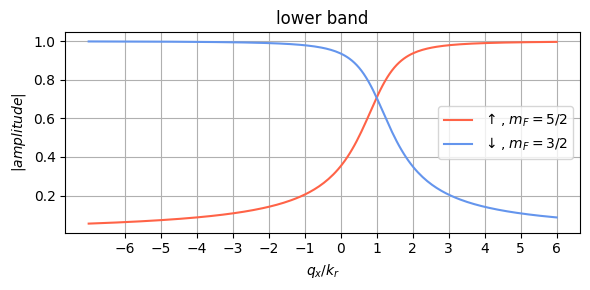

In [7]:
plt.figure(figsize=(6, 3))
plt.title("lower band")
plt.plot(qq, betas, color='tomato', label="$\\uparrow$, $m_F=5/2$")
plt.plot(qq, alphas, color='cornflowerblue', label="$\\downarrow$, $m_F=3/2$")
# plt.scatter(q_test, betas_test, color='tomato', s=50, edgecolors='k', zorder=5, label="$\\uparrow$, $m_F=5/2$")
# plt.scatter(q_test, alphas_test, color='cornflowerblue', s=50, edgecolors='k', zorder=5, label="$\\downarrow$, $m_F=3/2$")
plt.xticks(ticks)
plt.xlabel("$q_x/k_r$")
plt.ylabel("$|amplitude|$")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

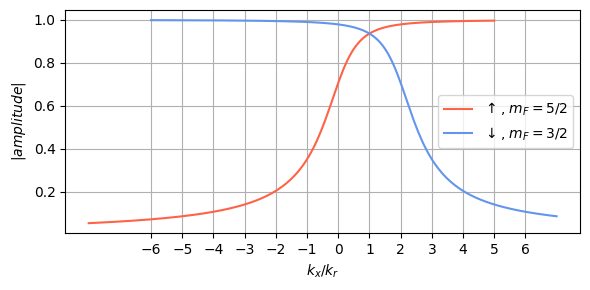

In [8]:
plt.figure(figsize=(6, 3))
plt.plot(qq - k_r, betas, color='tomato', label="$\\uparrow$, $m_F=5/2$")
plt.plot(qq + k_r, alphas, color='cornflowerblue', label="$\\downarrow$, $m_F=3/2$")
plt.xticks(ticks)
plt.xlabel("$k_x/k_r$")
plt.ylabel("$|amplitude|$")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

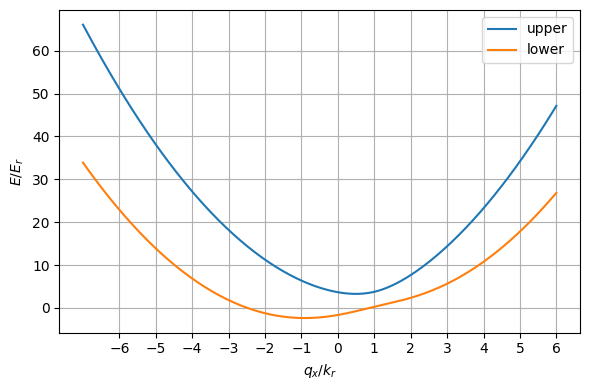

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(qq, E_up, label="upper")
plt.plot(qq, E_down, label="lower")
plt.xticks(ticks)
plt.xlabel("$q_x/k_r$")
plt.ylabel("$E/E_r$")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

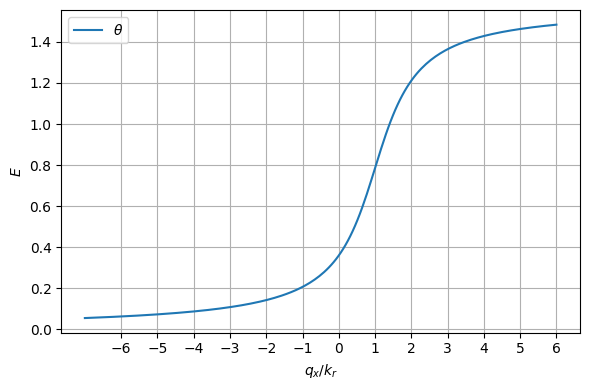

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(qq, thetas, label="$\\theta$")
plt.xticks(ticks)
plt.xlabel("$q_x/k_r$")
plt.ylabel("$E$")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

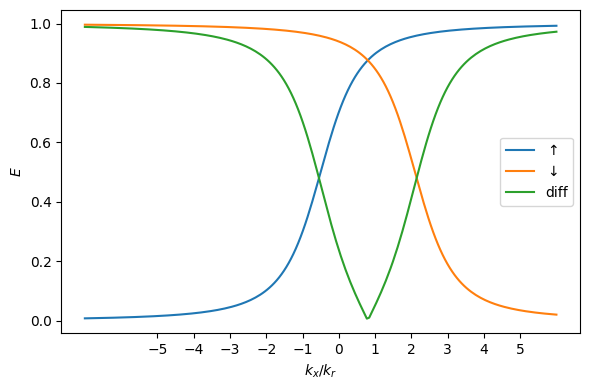

In [11]:
from quant_mech import ybsoc

kk = np.linspace(-5, 5, 200)

q_up = kk + k_r
q_down = kk - k_r

alphas = ybsoc.alpha(
    q_down,
    delta=delta,
    omega_R=omega_R,
    k_r=k_r,
    m_Yb=m_Yb,
)

betas = ybsoc.beta(
    q_up,
    delta=delta,
    omega_R=omega_R,
    k_r=k_r,
    m_Yb=m_Yb,
)

up_frac = np.square(np.abs(-betas))
down_frac = np.square(np.abs(alphas))

plt.figure(figsize=(6, 4))
plt.plot(qq, up_frac, label="$\\uparrow$")
plt.plot(qq, down_frac, label="$\\downarrow$")
plt.plot(qq, np.abs(down_frac - up_frac), label="diff")

plt.xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
plt.xlabel("$k_x/k_r$")
plt.ylabel("$E$")
plt.legend()
plt.tight_layout()
plt.show()